In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw_data = pd.read_csv('population_data.csv', index_col='id')
raw_data.head()

,Country (or dependency),Population 2025,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
id,,,,,,,,,,,
1,India,1463865525,0.89%,12929734,492,2973190,"−495,753",1.94,28.8,37.1%,17.78%
2,China,1416096094,−0.23%,"−3,225,184",151,9388211,"−268,126",1.02,40.1,67.5%,17.20%
3,United States,347275807,0.54%,1849236,38,9147420,1230663,1.62,38.5,82.8%,4.22%
4,Indonesia,285721236,0.79%,2233305,158,1811570,"−39,509",2.10,30.4,59.6%,3.47%
5,Pakistan,255219554,1.57%,3950390,331,770880,"−1,235,336",3.50,20.6,34.4%,3.10%


In [3]:
def get_rows_with_missing_values(data: pd.DataFrame) -> pd.DataFrame:
    """
    Возвращает DataFrame, содержащий только те строки,
    в которых есть хотя бы одно пропущенное значение.
    """
    rows_with_missing_data = raw_data.isnull().any(axis=1)
    return data[rows_with_missing_data]


In [4]:
def get_collums_with_missing_values(data: pd.DataFrame):
    """
    Возвращает DataFrame, содержащий только те столбцы,
    в которых есть хотя бы одно пропущенное значение.
    """
    cols_with_missing_data = raw_data.isnull().any(axis=0)
    return data.loc[:, cols_with_missing_data]

In [5]:
def fill_nan_values(cols: list, df: pd.DataFrame) -> pd.DataFrame: 
    """
    Заполнение медианнм значением пропусков в категориях
    """
    fill_this_rows = get_rows_with_missing_values(df).index
    obj_to_float(cols, df)
    
    for idx in fill_this_rows:
        density = df.loc[idx, 'Density (P/Km²)']
        new_urban_value = None
        if density > 7000:
            new_urban_value = 100.0
        elif 1000 < density <= 7000:
            
            median_val = df[(df['Density (P/Km²)'] > 1000) & (df['Density (P/Km²)'] <= 7000)]['Urban Pop %'].median()
            new_urban_value = median_val if pd.notna(median_val) else 90.0 
        elif 200 < density <= 1000:
            median_val = df[(df['Density (P/Km²)'] > 200) & (df['Density (P/Km²)'] <= 1000)]['Urban Pop %'].median()
            new_urban_value = median_val if pd.notna(median_val) else 75.0
        else: 
            median_val = df[df['Density (P/Km²)'] <= 200]['Urban Pop %'].median()
            new_urban_value = median_val if pd.notna(median_val) else 55.0

        df.loc[idx, 'Urban Pop %'] = new_urban_value
        print(f"Для id={idx} с плотностью {density:.0f} установлено значение урбанизации {new_urban_value:.2f}%")

    return df


In [6]:
def obj_to_float(cals: list, df: pd.DataFrame) -> pd.DataFrame:
    """ 
    убирает - и % у значений в датафрейме
    """
    for col in cals:
        if df[col].dtype == 'object':
            print(f"Преобразую столбец '{col}' в числовой формат...")
            df[col] = df[col].str.replace('−', '-', regex=False)
            df[col] = df[col].str.replace('%', '', regex=False).astype(float)

    return df


In [7]:
processed_data = fill_nan_values(['Yearly Change','Urban Pop %','World Share'], raw_data)
pd.set_option('display.max_rows', None)
processed_data.to_csv('demography.csv')
processed_data.head(15)

Преобразую столбец 'Yearly Change' в числовой формат...
Преобразую столбец 'Urban Pop %' в числовой формат...
Преобразую столбец 'World Share' в числовой формат...
Для id=53 с плотностью 32 установлено значение урбанизации 62.05%
Для id=106 с плотностью 7044 установлено значение урбанизации 100.00%
Для id=115 с плотностью 8387 установлено значение урбанизации 100.00%
Для id=134 с плотностью 19 установлено значение урбанизации 62.05%
Для id=135 с плотностью 365 установлено значение урбанизации 61.60%
Для id=153 с плотностью 2162 установлено значение урбанизации 82.50%
Для id=163 с плотностью 353 установлено значение урбанизации 61.60%
Для id=179 с плотностью 221 установлено значение урбанизации 61.60%
Для id=180 с плотностью 321 установлено значение урбанизации 61.60%
Для id=200 с плотностью 240 установлено значение урбанизации 61.60%
Для id=210 с плотностью 230 установлено значение урбанизации 61.60%
Для id=212 с плотностью 95 установлено значение урбанизации 62.05%
Для id=216 с плотно

,Country (or dependency),Population 2025,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
id,,,,,,,,,,,
1,India,1463865525,0.89,12929734,492,2973190,"−495,753",1.94,28.8,37.1,17.78
2,China,1416096094,-0.23,"−3,225,184",151,9388211,"−268,126",1.02,40.1,67.5,17.20
3,United States,347275807,0.54,1849236,38,9147420,1230663,1.62,38.5,82.8,4.22
4,Indonesia,285721236,0.79,2233305,158,1811570,"−39,509",2.10,30.4,59.6,3.47
5,Pakistan,255219554,1.57,3950390,331,770880,"−1,235,336",3.50,20.6,34.4,3.10
6,Nigeria,237527782,2.08,4848304,261,910770,"−15,258",4.30,18.1,54.9,2.89
7,Brazil,212812405,0.38,813832,25,8358140,"−217,283",1.60,34.8,91.4,2.59
8,Bangladesh,175686899,1.22,2124535,1350,130170,"−402,100",2.11,26.0,42.6,2.13
9,Russia,143997393,-0.57,"−823,030",9,16376870,"−251,822",1.47,40.3,75.0,1.75


## Демографические тенденции стран мира (2025)

####  Гипотеза 1: Уровень развития страны обратно пропорционален рождаемости.

####  В странах с более высоким медианным возрастом и уровнем урбанизации (условные индикаторы развития) коэффициент рождаемости (`Fert. Rate`) будет систематически ниже.

In [8]:
correlation_columns = ['Median Age', 'Urban Pop %', 'Fert. Rate']
correlation_matrix = processed_data[correlation_columns].corr().round(2)

print("Матрица корреляции:")
display(correlation_matrix)

Матрица корреляции:


,Median Age,Urban Pop %,Fert. Rate
Median Age,1.00,0.45,-0.85
Urban Pop %,0.45,1.00,-0.47
Fert. Rate,-0.85,-0.47,1.00


## Итоги по матрице корреляции

*   **Очень сильная отрицательная корреляция (-0.85) между `Median Age` и `Fert. Rate`**. Медианный возраст является главным индикатором, обратно связанным с рождаемостью: чем "старше" страна, тем ниже в ней рождаемость.
*   **Умеренная отрицательная корреляция (-0.47) между `Urban Pop %` и `Fert. Rate`**. Урбанизация также является фактором, связанным со снижением рождаемости, но ее влияние значительно слабее, чем у медианного возраста. Это говорит о том, что сам по себе факт проживания в городе не так сильно влияет на решение о количестве детей, как общие социально-экономические условия, отраженные в возрастной структуре населения.
*   **Умеренная положительная корреляция (0.45) между `Median Age` и `Urban Pop %`**. Это подтверждает, что наши индикаторы развития ("старение" и урбанизация) движутся в одном направлении. Этот показатель подтверждает, что процессы "старения" нации и урбанизации часто происходят параллельно, но связь между ними не является абсолютно строгой.   

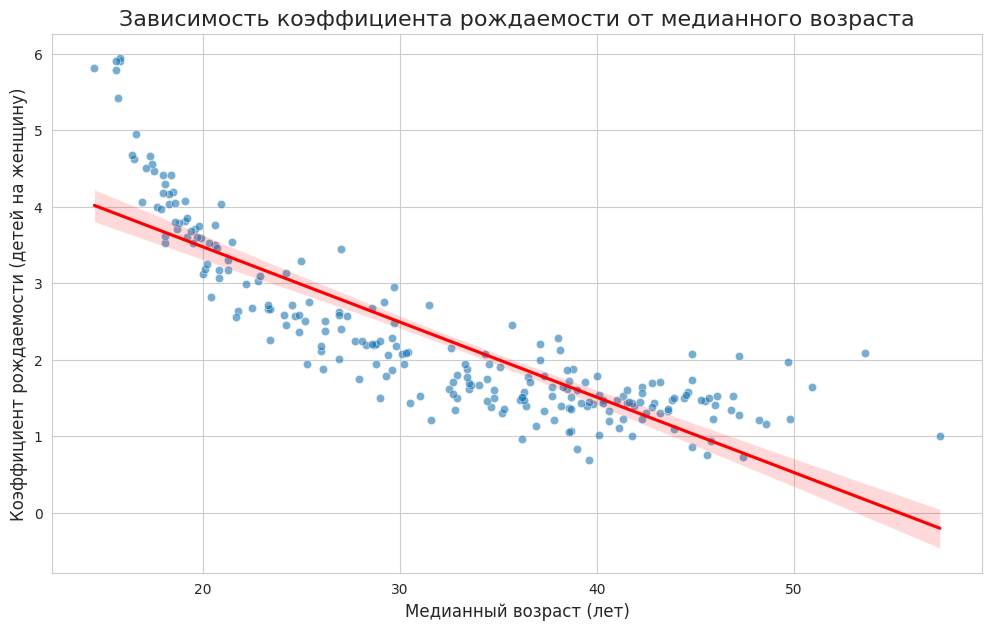

In [9]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))  

sns.scatterplot(data=processed_data, x='Median Age', y='Fert. Rate', alpha=0.6)
sns.regplot(data=processed_data, x='Median Age', y='Fert. Rate', scatter=False, color='red')

plt.title('Зависимость коэффициента рождаемости от медианного возраста', fontsize=16)
plt.xlabel('Медианный возраст (лет)', fontsize=12)
plt.ylabel('Коэффициент рождаемости (детей на женщину)', fontsize=12)


plt.show()

### Вывод 

#### Анализ показал, что главным демографическим фактором, обратно связанным с рождаемостью, является медианный возраст населения. Урбанизация также вносит свой вклад в снижение рождаемости, но выступает в роли второстепенного фактора.




### Гипотеза 2: Высокая плотность населения — удел стран с маленькой площадью.



  


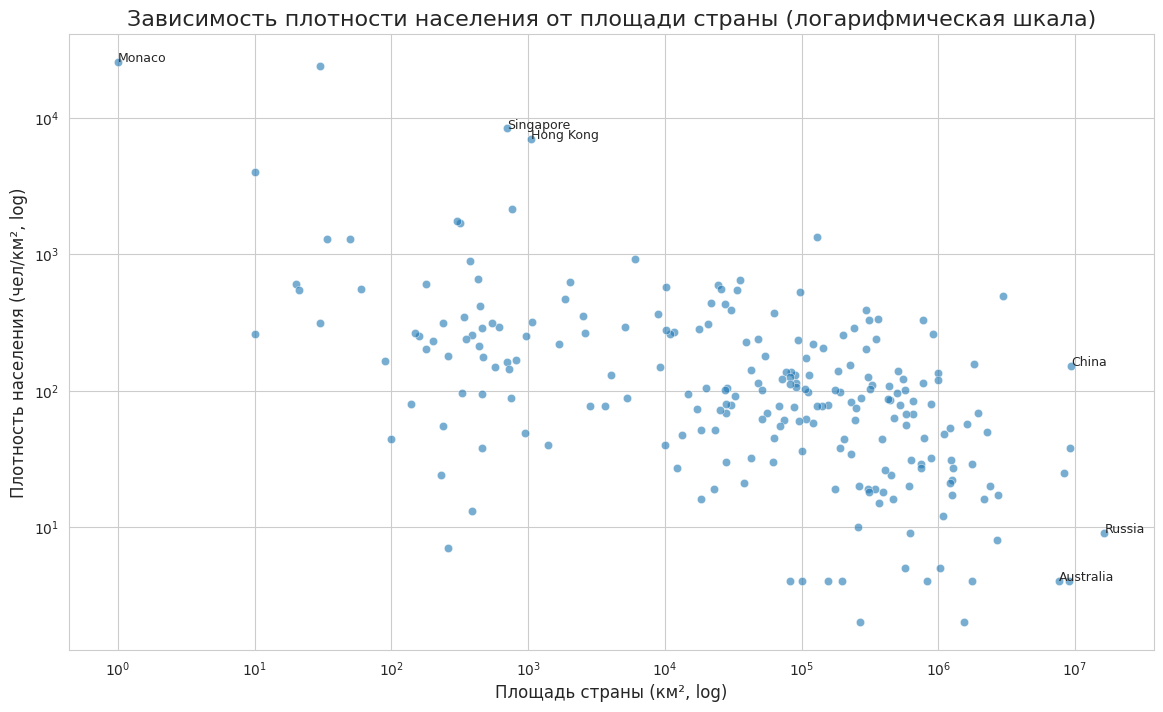

In [10]:
plt.figure(figsize=(14, 8))

sns.scatterplot(data=processed_data, x='Land Area (Km²)', y='Density (P/Km²)', alpha=0.6)

plt.xscale('log')
plt.yscale('log')


plt.title('Зависимость плотности населения от площади страны (логарифмическая шкала)', fontsize=16)
plt.xlabel('Площадь страны (км², log)', fontsize=12)
plt.ylabel('Плотность населения (чел/км², log)', fontsize=12)


countries_to_annotate = [
    'Monaco',
    'Singapore',
    'Hong Kong',
    'China',
    'Russia',
    'Australia'
    ]

for country in countries_to_annotate:
    country_data = processed_data[processed_data['Country (or dependency)'] == country]
    plt.text(country_data['Land Area (Km²)'].iloc[0], country_data['Density (P/Km²)'].iloc[0], country, fontsize=9)

## Выводы по Гипотезе 2

**Гипотеза полностью подтверждена.**

График наглядно демонстрирует сильную обратную зависимость между площадью страны и плотностью ее населения. 

*   В **левом верхнем углу** графика плотно сгруппированы страны с **минимальной площадью и максимальной плотностью** (Монако, Сингапур, Гонконг).
*   В **правом нижнем углу** находятся страны-гиганты с **огромной площадью и очень низкой плотностью** (Россия, Канада, Австралия).

Общий тренд облака точек идет из левого верхнего угла в правый нижний, что визуально подтверждает: чтобы достичь высокой плотности населения, страна должна быть небольшой по территории.